# Figure S3 — Metrics with ichorCNA at the fixed TF ≥ 0.03 cutoff

Same comparison as Figure 3a/b (healthy vs BRCA+CRC, 10 outer folds), but
ichorCNA is evaluated at the community-standard tumor-fraction cutoff of
0.03 (Adalsteinsson et al.) instead of the CV-derived 95%-specificity
threshold. The ROC panel still shows the ichorCNA curve for AUC; the ★ marks
the fixed operating point. The other three methods are unchanged from Fig 3.

**Source data**: `data/fig3_predictions.csv` + `data/fig3_config.csv` — the
same files as Figure 3 (written by `export/export_fig3.py`); this figure is a
re-thresholding of the identical predictions. No pickles, no cluster paths,
no network. Run top to bottom from `src/figures/`.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from sklearn.metrics import roc_curve, auc

APPROACH_COLORS = {
    "RNA": "#CA3542", "ATAC": "#ECB22E",
    "Data-driven": "#0173B2", "ichorCNA": "#6A3D9A",
}
METHOD_LABELS = {"data_driven": "Data-driven", "atac": "ATAC", "rna": "RNA", "ichorcna": "ichorCNA"}
ICHOR_FIXED_THRESHOLD = 0.03

pred = pd.read_csv("data/fig3_predictions.csv")
config = pd.read_csv("data/fig3_config.csv")
display(config)

,method,feature,classifier,weighting_function,top_genes,source_dir,selection_mean_auc
0,data_driven,griffin_diff,Support Vector Machine,mean_diff,14224.0,nested_cv_results_cris/brca_crc_dd,0.950595
1,rna,rcov,Multi-Layer Perceptron,NaN,NaN,nested_cv_results_cris/brca_crc_rna,0.680357
2,atac,ulz_atac_tfbs_features,Support Vector Machine,NaN,NaN,nested_cv_results_cris/brca_crc_atac,0.912798
3,ichorcna,ichorcna_tf,NaN,NaN,NaN,accessory_files/cris_stage_vaf_coverage_ichor_...,NaN


In [2]:
def expand(df):
    return df.loc[df.index.repeat(df["n_rows_in_source"])]


def fold_frames(method):
    df = pred[(pred["method"] == method) & pred["fold"].notna()]
    return [expand(g).dropna(subset=["score"]) for _, g in df.groupby("fold")]


def binary_metrics(y, y_hat):
    tn = int(np.sum((y == 0) & (y_hat == 0)))
    fp = int(np.sum((y == 0) & (y_hat == 1)))
    fn = int(np.sum((y == 1) & (y_hat == 0)))
    tp = int(np.sum((y == 1) & (y_hat == 1)))
    m = {"recall": tp / (tp + fn) if tp + fn else 0.0,
         "accuracy": (tp + tn) / (tp + tn + fp + fn),
         "specificity": tn / (tn + fp) if tn + fp else 0.0,
         "fpr": fp / (fp + tn) if fp + tn else 0.0,
         "tpr": tp / (tp + fn) if tp + fn else 0.0}
    if tp + fp:  # precision/F1 undefined when no positive predictions
        m["precision"] = tp / (tp + fp)
        m["f1-score"] = 2 * m["precision"] * m["recall"] / (m["precision"] + m["recall"]) \
            if (m["precision"] + m["recall"]) else 0.0
    return m


approach_metrics, ichor_op_points = {}, []
for method in METHOD_LABELS:
    per_fold = []
    for g in fold_frames(method):
        if method == "ichorcna":
            thr = ICHOR_FIXED_THRESHOLD
        else:
            thr = g["threshold_95spec"].iloc[0]
        m = binary_metrics(g["y_true"].to_numpy(), (g["score"] >= thr).to_numpy().astype(int))
        per_fold.append(m)
        if method == "ichorcna":
            ichor_op_points.append((m["fpr"], m["tpr"]))
    keys = ["precision", "recall", "f1-score", "accuracy", "specificity"]
    approach_metrics[method] = {k: [m[k] for m in per_fold if k in m] for k in keys}

## Assemble Figure S3 (ROC with fixed operating point + metrics at TF ≥ 0.03)

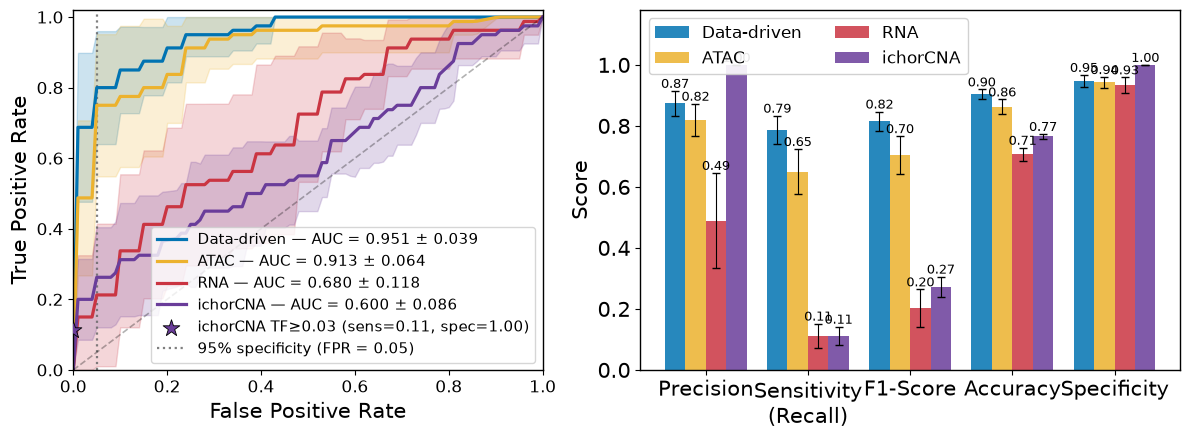

In [3]:
fig, (ax_roc, ax_metrics) = plt.subplots(
    1, 2, figsize=(12, 4.5), gridspec_kw={"width_ratios": [1, 1.15]})

base_fpr = np.linspace(0, 1, 101)
for method in ["data_driven", "atac", "rna", "ichorcna"]:
    name = METHOD_LABELS[method]
    color = APPROACH_COLORS[name]
    tprs, aucs = [], []
    for g in fold_frames(method):
        fpr, tpr, _ = roc_curve(g["y_true"], g["score"])
        tprs.append(interp1d(fpr, tpr, kind="linear")(base_fpr))
        aucs.append(auc(fpr, tpr))
    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[0], mean_tpr[-1] = 0, 1
    std_tpr = np.std(tprs, axis=0)
    ax_roc.plot(base_fpr, mean_tpr, color=color, linewidth=2.3,
                label=f"{name} — AUC = {np.mean(aucs):.3f} ± {np.std(aucs):.3f}")
    ax_roc.fill_between(base_fpr, np.maximum(mean_tpr - std_tpr, 0),
                        np.minimum(mean_tpr + std_tpr, 1), color=color, alpha=0.2)

mean_op_fpr = np.mean([p[0] for p in ichor_op_points])
mean_op_tpr = np.mean([p[1] for p in ichor_op_points])
ax_roc.scatter(mean_op_fpr, mean_op_tpr, color=APPROACH_COLORS["ichorCNA"], s=160,
               zorder=6, marker="*", edgecolors="black", linewidths=0.6,
               label=(f"ichorCNA TF≥{ICHOR_FIXED_THRESHOLD:.2f} "
                      f"(sens={mean_op_tpr:.2f}, spec={1 - mean_op_fpr:.2f})"))

ax_roc.plot([0, 1], [0, 1], "k--", alpha=0.3, linewidth=1.2)
ax_roc.axvline(x=0.05, color="dimgray", linestyle=":", linewidth=1.6, alpha=0.85,
               zorder=1, label="95% specificity (FPR = 0.05)")
ax_roc.set_xlim(0, 1)
ax_roc.set_ylim(0, 1.02)
ax_roc.set_xlabel("False Positive Rate", fontsize=15)
ax_roc.set_ylabel("True Positive Rate", fontsize=15)
ax_roc.legend(loc="lower right", fontsize=10.5, frameon=True)
ax_roc.tick_params(labelsize=12)
for spine in ax_roc.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_color("black")

metric_names = ["Precision", "Sensitivity\n(Recall)", "F1-Score", "Accuracy", "Specificity"]
metric_keys = ["precision", "recall", "f1-score", "accuracy", "specificity"]
x = np.arange(len(metric_names))
width = 0.2
order = [("data_driven", "Data-driven"), ("atac", "ATAC"), ("rna", "RNA"), ("ichorcna", "ichorCNA")]
for idx, (method, label) in enumerate(order):
    m = approach_metrics[method]
    means = [np.mean(m[k]) if m[k] else 0 for k in metric_keys]
    errs = [np.std(m[k], ddof=1) / np.sqrt(len(m[k])) if len(m[k]) > 1 else 0 for k in metric_keys]
    yerr_lo = [min(e, mu) for mu, e in zip(means, errs)]
    yerr_hi = [min(e, 1.0 - mu) for mu, e in zip(means, errs)]
    offset = (idx - (len(order) - 1) / 2) * width
    ax_metrics.bar(x + offset, means, width, yerr=[yerr_lo, yerr_hi], label=label,
                   color=APPROACH_COLORS[label], alpha=0.85, capsize=3,
                   error_kw={"elinewidth": 0.8})
    for i, v in enumerate(means):
        ax_metrics.text(i + offset, v + errs[i], f"{v:.2f}", ha="center", va="bottom", fontsize=9)
ax_metrics.set_ylabel("Score", fontsize=15)
ax_metrics.set_xticks(x)
ax_metrics.set_xticklabels(metric_names, fontsize=14)
ax_metrics.legend(fontsize=12, loc="upper left", ncol=2, framealpha=0.9)
ax_metrics.set_ylim(0, 1.18)
ax_metrics.tick_params(labelsize=15)
for spine in ax_metrics.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_color("black")

plt.tight_layout()
os.makedirs("output", exist_ok=True)
fig.savefig("output/figS3.png", dpi=300, bbox_inches="tight")
fig.savefig("output/figS3.pdf", bbox_inches="tight")
plt.show()

## Check against the manuscript

S3 caption: at the 0.03 cutoff ichorCNA precision reaches 1 (specificity 1)
while sensitivity drops relative to the CV-derived threshold in Fig 3b.

In [4]:
m = approach_metrics["ichorcna"]
print("ichorCNA at TF ≥ 0.03 (mean over folds):")
for k in metric_keys:
    print(f"  {k:<12} {np.mean(m[k]):.3f}  (n folds contributing: {len(m[k])})")
print(f"\nfixed operating point: sens={mean_op_tpr:.2f}, spec={1 - mean_op_fpr:.2f}")

ichorCNA at TF ≥ 0.03 (mean over folds):
  precision    1.000  (n folds contributing: 7)
  recall       0.113  (n folds contributing: 10)
  f1-score     0.273  (n folds contributing: 7)
  accuracy     0.766  (n folds contributing: 10)
  specificity  1.000  (n folds contributing: 10)

fixed operating point: sens=0.11, spec=1.00
